In [1]:
# --- Celda 1.1: Importaciones y Carga de Librerías Offline ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import ROOT
import time
import traceback
from multiprocessing import Pool, cpu_count # <-- Importamos Pool
from functools import partial

Welcome to JupyROOT 6.30/04


In [2]:
# Esta es la parte MÁS IMPORTANTE:
# Asegúrate de que estás corriendo este Jupyter Lab desde una terminal
# donde ANTES hiciste: source /ruta/a/auger/offline/this-auger-offline.sh

AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError(
        "AUGEROFFLINEROOT no definido. "
        "Reinicia Jupyter Lab desde una terminal donde hayas "
        "hecho: "
        " 'aug_set_version offline 4.0.1-icrc23-prod1-root6' "   
        " 'source /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6/bin/this-auger-offline.sh'."
    )

print(f"AUGEROFFLINEROOT encontrado en: {AugerOfflineRoot}")

# Cargar las librerías necesarias
print("Cargando librerías de Auger Offline...")
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    lib_path = os.path.join(AugerOfflineRoot, "lib", lib)
    if not os.path.exists(lib_path):
        raise FileNotFoundError(f"No se encontró la librería: {lib_path}")
    
    # Usamos gSystem.Load que es más robusto en PyROOT
    status = ROOT.gSystem.Load(lib_path)
    if status < 0:
        raise ImportError(f"Error cargando la librería: {lib_path}")

print("Librerías cargadas correctamente. ¡Listo para trabajar! 🚀")

AUGEROFFLINEROOT encontrado en: /srv/software/amd64/ubuntu/24.04/auger/offline/4.0.1-icrc23-prod1-root6
Cargando librerías de Auger Offline...
Librerías cargadas correctamente. ¡Listo para trabajar! 🚀


In [3]:
# --- Celda 2.1: Funciones Auxiliares y Principales (con nMuones_MC) ---

# --- getModuleList sigue igual ---
def getModuleList(counter, sim=True):
    possibleModules = range(0, 6) if sim else range(100, 116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules

# ❗️ Renombramos la función para no confundirla
def readADST_surface_v7(fname, is_mc_simulation=True):
    """
    Leer un archivo ADST (1 fila por MÓDULO).
    Itera sobre MDEvent.
    Guarda un flag 'is_sd_saturated'.
    ❗️ AHORA TAMBIÉN GUARDA 'nMuones_MC' por módulo.
    """
    
    print(f"Iniciando lectura de: {os.path.basename(fname)}")
    
    if not os.path.exists(fname):
        print(f"Advertencia: Archivo no encontrado {fname}")
        return pd.DataFrame() # Retorna DF vacío

    files = ROOT.std.vector('string')()
    files.push_back(fname)

    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = [] 
    event_count = 0
    start_time = time.time()

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        event_count += 1
        if event_count % 500 == 0:
            print(f"... procesados {event_count} eventos.")

        event_id_lluvia = event.GetEventId()
        
        MCShower = event.GetGenShower()
        mc_energy = MCShower.GetEnergy()
        logE_MC = np.log10(mc_energy) if mc_energy > 0 else np.nan
        theta_MC = MCShower.GetZenith() * 180.0 / np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0 / np.pi
        primary = MCShower.GetShortPrimaryName()
        
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        rec_energy = sShower.GetEnergy()
        logE_REC = np.log10(rec_energy) if rec_energy > 0 else np.nan
        theta_REC = sShower.GetZenith() * 180.0 / np.pi
        phi_REC = sShower.GetAzimuth() * 180.0 / np.pi
        
        shower_azimuth_rec = sShower.GetAzimuth()
        
        mEvent = event.GetMDEvent()
        counterIterator = mEvent.CountersBegin()
        countersEnd = mEvent.CountersEnd()
        
        while counterIterator != countersEnd:
            
            counter = counterIterator.__deref__()
            counterId = counter.GetId()
            sdId = counter.GetSdPartnerId()

            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            
            if sdStation is None:
                counterIterator += 1
                continue 
            
            # --- ❗️ OBTENEMOS EL SIM COUNTER ❗️ ---
            # Este es el objeto que tiene la info MC del UMD
            simCounter = mEvent.GetSimCounter(counterId)
            if simCounter is None:
                # Si no hay simCounter (raro en MC), no podemos 
                # obtener nMuones_MC, así que saltamos
                counterIterator += 1
                continue
            # --- ❗️ FIN ❗️ ---

            is_sd_saturated = sdStation.IsLowGainSaturated()
            r = sdStation.GetSPDistance()
            r_core = r
            r_core_err = sdStation.GetSPDistanceError()
            sdSignal = sdStation.GetTotalSignal()
            sdSignal_err = sdStation.GetTotalSignalError()
            sdMuonSignal = sdStation.GetMuonSignal()
            
            station_azimuth_sp = sdStation.GetAzimuthSP()
            if sdId >= 90000 and sdId < 100000:
                phi_rel = station_azimuth_sp
            else:
                phi_rel = station_azimuth_sp - shower_azimuth_rec

            x_plane = r * np.cos(phi_rel)
            y_plane = r * np.sin(phi_rel)
            phi_plane = (phi_rel + 2 * np.pi) % (2 * np.pi)
            
            modules = getModuleList(counter, sim=is_mc_simulation)
            for module in modules:
                
                # Señal Reconstruida (REC)
                nMuones_REC = module.GetNumberOfEstimatedMuons()
                moduleId = module.GetId()

                if module.IsCandidate(): status = "candidate"
                elif module.IsSaturated(): status = "saturated"
                elif module.IsRejected(): status = "rejected"
                elif module.IsSilent(): status = "silent"
                else: status = "undefined"
                
                # --- ❗️ CÁLCULO DE MUONES MC (COMO CARMI) ❗️ ---
                nMuones_MC_module = 0.0
                channelIterator = module.ChannelsBegin()
                channelsEnd = module.ChannelsEnd()
                
                while channelIterator != channelsEnd:
                    channel = channelIterator.__deref__()
                    channelId = channel.GetId()
                    
                    if simCounter.HasSimScintillatorByChannel(moduleId, channelId):
                        mdSimScintillator = simCounter.GetSimScintillatorByChannelId(moduleId, channelId)
                        nMuones_MC_module += mdSimScintillator.GetNumberOfInjectedMuons()
                    
                    channelIterator += 1
                # --- ❗️ FIN DEL CÁLCULO ❗️ ---

                data.append({
                    "event_id": event_id_lluvia,
                    "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
                    "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
                    
                    "counterId": counterId,
                    "moduleId": moduleId,
                    "nMuones_REC": nMuones_REC,   # <-- ❗️ RENOMBRADO
                    "nMuones_MC": nMuones_MC_module, # <-- ❗️ NUEVA COLUMNA
                    "module_status": status,
                    "is_sd_saturated": is_sd_saturated,
                    
                    "x_plane": x_plane,
                    "y_plane": y_plane,
                    "phi_plane": phi_plane,
                    "r_core": r_core,
                    "r_core_err": r_core_err,
                    
                    "sdId": sdId, 
                    "sdSignal": sdSignal,
                    "sdSignal_err": sdSignal_err,
                    "sdMuonSignal": sdMuonSignal
                })
            
            counterIterator += 1
        
    end_time = time.time()
    elapsed = end_time - start_time
    
    print(f"Lectura completa. Total de eventos leídos: {event_count}")
    print(f"Tiempo total de lectura: {elapsed:.2f} segundos.")
    print(f"Total de 'MÓDULOS' (filas) extraídos: {len(data)}")

    df = pd.DataFrame(data)
    return df

In [4]:
# -----------------------------------------------------------------
# FUNCIÓN "TRABAJADORA"
# ❗️ 2. AHORA ACEPTA 'output_dir' COMO ARGUMENTO
# -----------------------------------------------------------------
def process_file_wrapper(root_fpath, output_dir):
    
    # 1. Definir rutas
    filename = os.path.basename(root_fpath)
    output_filename = filename.replace(".root", ".parquet")
    output_path = os.path.join(output_dir, output_filename)
    
    # 2. Evitar reprocesar
    if os.path.exists(output_path):
        return f"INFO: El archivo ya existe, saltando: {output_filename}"

    # 3. Imprimir estado
    print(f"► [Iniciando]: {filename}")
    
    try:
        # ----- INICIO DEL TRABAJO -----
        start_file_time = time.time()
        
        # 1. Leer el .root (¡Llama a la función de la Celda 2.1!)
        # (Asegurate de que tu Celda 2.1 se llame 'readADST_surface' 
        # o cambiá el nombre aquí abajo)
        df = readADST_surface_v7(root_fpath) 
        
        if df.empty:
            return f"INFO: Archivo vacío o sin datos UMD. Saltando: {filename}"

        # 2. Extraer metadatos del nombre de archivo
        try:
            parts = filename.split('_')
            df["model_mc"] = parts[0]
            df["e_min_mc"] = float(parts[1]) / 10.0
            df["e_max_mc"] = float(parts[2]) / 10.0
            df["primary_name_mc"] = parts[3]
            run_part = parts[-1].replace('.root', '')
            df["run_number"] = int(run_part.replace('Run', ''))
        except Exception as e_parse:
            print(f"  Advertencia: No se pudo parsear metadata en {filename}: {e_parse}")

        # 3. Guardar en Parquet
        df.to_parquet(
            output_path,
            compression="snappy",
            index=False
        )
        
        # 4. Liberar memoria
        del df
        
        end_file_time = time.time()
        elapsed = end_file_time - start_file_time
        return f"✔ [Éxito]: {filename} -> {output_filename} ({elapsed:.2f}s)"

        # ----- FIN DEL TRABAJO -----

    except Exception as e:
        # Si algo falla, retornamos el string de error
        return f"❌ [ERROR] en {filename}: {e}\n{traceback.format_exc()}"

# Prueba

In [5]:
print("--- INICIANDO PROCESO SERIAL (MODO DE PRUEBA: 1 ARCHIVO) ---")
start_total_time = time.time()

# --- 1. Configuración de Rutas ---
base_path = "/srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium"
output_dir = "/home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/"

os.makedirs(output_dir, exist_ok=True)
print(f"Buscando archivos en: {base_path}")
print(f"Los archivos .parquet se guardarán en: {output_dir}")

# --- 2. Encontrar todos los archivos ---
all_root_files = glob.glob(os.path.join(base_path, "*.root"))
all_root_files.sort()

if not all_root_files:
    print(f"¡Error! No se encontraron archivos .root en: {base_path}")
else:
    print(f"Encontrados {len(all_root_files)} archivos .root para procesar.")

# --- 3. Bucle de Procesamiento Serial ---
exitos = 0
errores = 0

for i, root_fpath in enumerate(all_root_files):
    
    filename = os.path.basename(root_fpath)
    output_filename = filename.replace(".root", ".parquet")
    output_path = os.path.join(output_dir, output_filename)
    
    print(f"\n--- Procesando archivo {i+1}/{len(all_root_files)} ---")
    print(f"► {filename}")
    
    # Evita reprocesar archivos que ya existen
    if os.path.exists(output_path):
        print(f"INFO: El archivo ya existe, saltando: {output_filename}")
        continue

    try:
        # ----- INICIO DEL TRABAJO -----
        start_file_time = time.time()
        
        # 1. Leer el .root (usa la Celda 2.1)
        df = readADST_surface_v7(root_fpath)
        
        if df.empty:
            print(f"INFO: Archivo vacío o sin datos UMD. Saltando.")
            continue

        # 2. Extraer metadatos del nombre de archivo
        try:
            parts = filename.split('_')
            df["model_mc"] = parts[0]
            df["e_min_mc"] = float(parts[1]) / 10.0
            df["e_max_mc"] = float(parts[2]) / 10.0
            df["primary_name_mc"] = parts[3]
            run_part = parts[-1].replace('.root', '')
            df["run_number"] = int(run_part.replace('Run', ''))
        except Exception as e_parse:
            print(f"  Advertencia: No se pudo parsear metadata: {e_parse}")

        # 3. Guardar en Parquet
        df.to_parquet(
            output_path,
            compression="snappy",
            index=False
        )
        
        # 4. Liberar memoria
        del df
        
        end_file_time = time.time()
        print(f"✔ [Éxito]: Guardado como {output_filename}")
        print(f"Tiempo de este archivo: {end_file_time - start_file_time:.2f}s")
        exitos += 1
        
        # ----- FIN DEL TRABAJO -----
        
        # ❗️ LÍNEA DE PRUEBA AÑADIDA ❗️
        print("\n--- ¡PRUEBA DETENIDA! Saliendo del bucle después de 1 archivo. ---")
        break  # Esto detiene el 'for' después de la primera pasada exitosa
               # ELIMINÁ ESTA LÍNEA para procesar todos los archivos.

    except Exception as e:
        print(f"❌ [ERROR] en {filename}: {e}")
        print(traceback.format_exc())
        errores += 1

# --- 4. Resumen Final ---
end_total_time = time.time()
print("\n\n--- Proceso Completado ---")
print(f"Tiempo total: {(end_total_time - start_total_time) / 60:.2f} minutos")
print(f"Total de archivos procesados: {exitos + errores}")
print(f"Éxitos: {exitos}")
print(f"Errores: {errores}")
print(f"¡Listo! Tu archivo .parquet de prueba está en: {output_dir}")

--- INICIANDO PROCESO SERIAL (MODO DE PRUEBA: 1 ARCHIVO) ---
Buscando archivos en: /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium
Los archivos .parquet se guardarán en: /home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/
Encontrados 20 archivos .root para procesar.

--- Procesando archivo 1/20 ---
► SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
Iniciando lectura de: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
... procesados 500 eventos.
... procesados 1000 eventos.
Lectura completa. Total de eventos leídos: 1223
Tiempo total de lectura: 407.68 segundos.
Total de 'MÓDULOS' (filas) extraídos: 81909
✔ [Éxito]: Guardado como SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet
Tiempo de este archivo: 415.07s

--- ¡PRUEBA DETENIDA! Saliendo del bucle después de 1 archivo. ---


--- Proceso Completado ---
Tiempo total: 6.92 minutos
Total de archivos procesados: 1
Éxitos: 1
Errores: 0
¡

  input file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class Detector read from file /srv/data/Malargue/icrc2025/test7/IdealMC_CORSIKA/MdSdInfill_CORSIKA78010_FLUKA/SIB23e/17.5_18.0/helium/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.root
   has the same version (=27) as the active class but a different checksum.
   You should update the version to ClassDef(Detector,28).
   Do not try to write objects with the current class definition,
   the files will not be readable.

Warning in <TStreamerInfo::CompareContent>: The following data member of
the on-file layout version 27 of class 'Detector' differs from 
the in-memory layout version 27:
   map<int,EyePointingIdMap> fTelPointingIds; //
vs
   map<int,map<int,TString> > fTelPointingIds; //
Warning in <TStreamerInfo::BuildCheck>: 
   The 

In [6]:
# --- Cargar tu nuevo DataFrame (1 fila por MÓDULO) ---
parquet_path = "/home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet"
df_new = pd.read_parquet(parquet_path)

print(f"DataFrame 'df_new' cargado con {len(df_new)} filas (MÓDULOS).")

# --- 1. Inspeccionar las nuevas columnas ---
print("\n--- Head (con nuevas columnas) ---")

print(df_new.head(10)) # Muestro 10 filas para ver el cambio de módulo

# --- 2. ¡La verificación CLAVE! ---
# Ver qué estados de módulo capturaste
print("\n--- Conteo de 'module_status' ---")
print(df_new['module_status'].value_counts())

DataFrame 'df_new' cargado con 81909 filas (MÓDULOS).

--- Head (con nuevas columnas) ---
                                            event_id    logE_MC   theta_MC  \
0  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
1  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
2  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
3  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
4  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
5  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
6  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
7  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
8  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
9  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   

       phi_MC primary   logE_REC  theta_REC     phi

In [7]:
print(df_new['counterId'].unique())

[ 90000  90001  90002  90003  90004  90005  90006  90007  90008  90009
  90010  90011 104009 104010 104021 104022 104023 104040 104041 104032
 104033 104054 104055 104056 104075 104215 104216 104074 104214 104218
 104001 104002 104003 104004 104005 104007 104008 104011 104012 104018
 104019 104013 104025 104026 104027 104044 104045 104047 104067 104015
 104016 104017 104029 104030 104031 104052 104024 104043 104014 104028
 104049 104053 104073 104212 104213 104217 104048 104051 104006 104034
 104035 104057 104058 104046 104020 104036 104039 104038 104037 104060
 104061 104042 104059 104163 104064 104161 104050 104096 104079 104160
 104066 104068 104106 104072 104097 104120 104188 104062 104158 104132
 104151 104095 104150 104114 104082 104093 104116 104069 104130 104063
 104070 104078 104081 104092 104129 104065 104085 104119 104147 104071
 104125 104193 104099 104136 104137 104076 104098 104091 104206 104115
 104126 104122 104077 104133 104101]



--- Testeando Counter 90000 (Anillo Denso) ---
count    3651.000000
mean        3.148519
std         3.090932
min         0.000000
25%         0.038738
50%         5.840026
75%         6.246073
max         6.283097
Name: phi_plane, dtype: float64


--- Testeando Counter 104022 (Infill Normal) ---
count    609.000000
mean       3.279003
std        1.935104
min        0.000000
25%        1.659097
50%        3.416675
75%        4.967874
max        6.279960
Name: phi_plane, dtype: float64


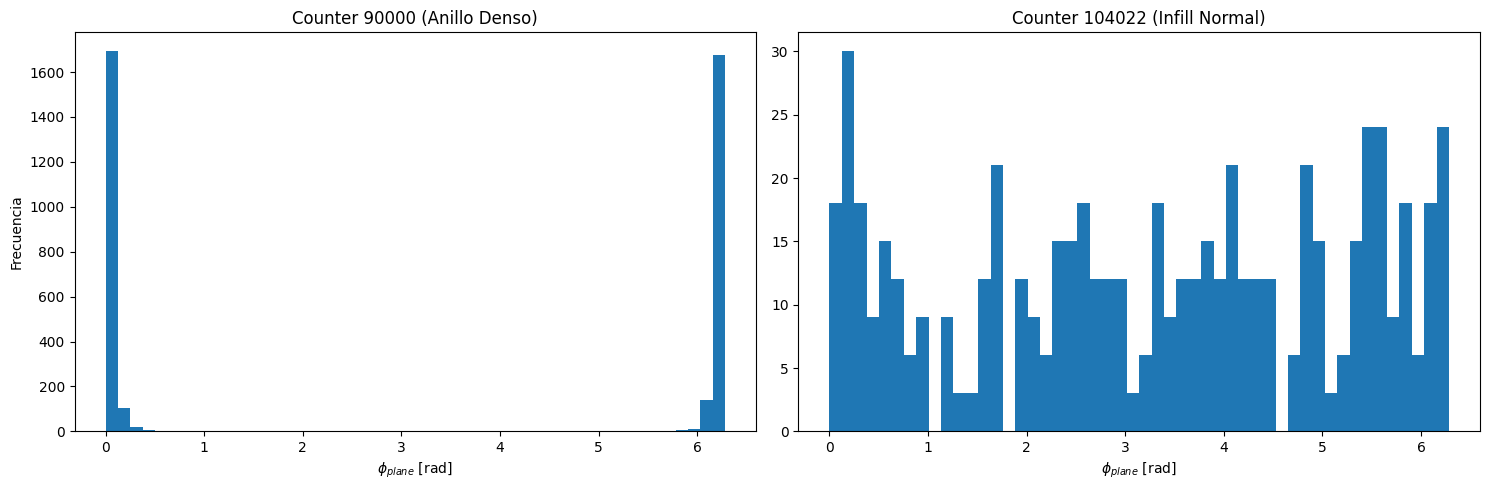

In [9]:
# --- 1. TEST NUMÉRICO ---

print("\n--- Testeando Counter 90000 (Anillo Denso) ---")
df_90000 = df_new[df_new['counterId'] == 90000]

if not df_90000.empty:
    print(df_90000['phi_plane'].describe())
else:
    print("No se encontraron datos para el Counter 90000 en este archivo.")

print("\n" + "="*30 + "\n")

print("--- Testeando Counter 104022 (Infill Normal) ---")
df_104022 = df_new[df_new['counterId'] == 104022] # (O cualquier 104xxx)

if not df_104022.empty:
    print(df_104022['phi_plane'].describe())
else:
    print("No se encontraron datos para el Counter 104022 en este archivo.")

# --- 2. TEST VISUAL (Histogramas) ---
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Histograma para el 90000
if not df_90000.empty:
    axs[0].hist(df_90000['phi_plane'], bins=50, range=(0, 2*np.pi))
    axs[0].set_title("Counter 90000 (Anillo Denso)")
    axs[0].set_xlabel(r"$\phi_{plane}$ [rad]")
    axs[0].set_ylabel("Frecuencia")
else:
    axs[0].set_title("Counter 90000 (Sin datos)")

# Histograma para el 104022
if not df_104022.empty:
    axs[1].hist(df_104022['phi_plane'], bins=50, range=(0, 2*np.pi))
    axs[1].set_title("Counter 104022 (Infill Normal)")
    axs[1].set_xlabel(r"$\phi_{plane}$ [rad]")
else:
    axs[1].set_title("Counter 104022 (Sin datos)")

plt.tight_layout()
plt.show()

Cargando archivo de prueba: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet
DataFrame 'df_test' cargado con 81909 filas (módulos).
Analizando 67389 módulos con señal MC.


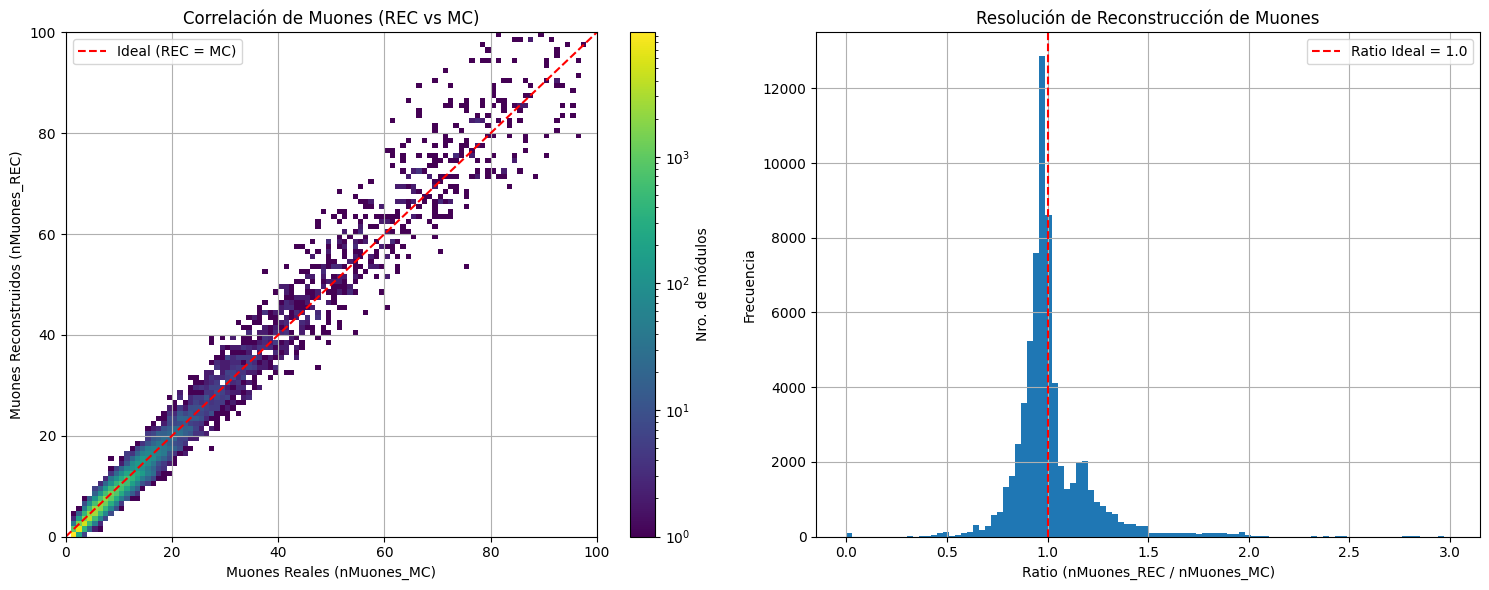


--- Métricas del Ratio (REC / MC) ---
  Promedio (mean): 1.013
  Mediana (median): 0.981
  Resolución (std dev): 0.196


In [12]:
from matplotlib.colors import LogNorm # <-- ❗️❗️ LÍNEA CORREGIDA ❗️❗️

# --- 1. Cargar el DataFrame de prueba (v7) ---
# ❗️ Apuntamos a la nueva carpeta parquet_v7/
parquet_dir_v7 = "/home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/"
all_parquet_files_v7 = glob.glob(os.path.join(parquet_dir_v7, "*.parquet"))

if not all_parquet_files_v7:
    print(f"¡ERROR! No se encontró ningún archivo en {parquet_dir_v7}")
    print("Por favor, corré la celda anterior (Bloque 5.1) primero.")
else:
    # Cargamos el primer archivo que encuentre
    parquet_path_v7 = all_parquet_files_v7[0]
    print(f"Cargando archivo de prueba: {os.path.basename(parquet_path_v7)}")
    
    df_test = pd.read_parquet(parquet_path_v7)
    print(f"DataFrame 'df_test' cargado con {len(df_test)} filas (módulos).")

    # Filtramos datos "buenos" para el test
    status_buenos = ['candidate', 'rejected', 'saturated']
    
    # Filtramos también por nMuones_MC > 0 para que el ratio tenga sentido
    df_test_limpio = df_test[
        (df_test['module_status'].isin(status_buenos)) &
        (df_test['nMuones_MC'] > 0)
    ].copy()
    
    print(f"Analizando {len(df_test_limpio)} módulos con señal MC.")

    # --- 2. Plot 1: Correlación 2D ---
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    # Usamos un histograma 2D porque un scatter sería una mancha
    h = axs[0].hist2d(
        df_test_limpio['nMuones_MC'], 
        df_test_limpio['nMuones_REC'],
        bins=100, 
        norm=LogNorm(), # Escala logarítmica en color
        range=[[0, 100], [0, 100]] # Rango (ajustar si es necesario)
    )
    fig.colorbar(h[3], ax=axs[0], label='Nro. de módulos')
    
    # Línea ideal (y=x)
    axs[0].plot([0, 100], [0, 100], 'r--', label='Ideal (REC = MC)')
    axs[0].set_xlabel("Muones Reales (nMuones_MC)")
    axs[0].set_ylabel("Muones Reconstruidos (nMuones_REC)")
    axs[0].set_title("Correlación de Muones (REC vs MC)")
    axs[0].legend()
    axs[0].grid(True)

    # --- 3. Plot 2: Histograma del Ratio ---
    df_test_limpio['muon_ratio'] = df_test_limpio['nMuones_REC'] / df_test_limpio['nMuones_MC']
    
    axs[1].hist(df_test_limpio['muon_ratio'], bins=100, range=[0, 3])
    axs[1].set_xlabel("Ratio (nMuones_REC / nMuones_MC)")
    axs[1].set_ylabel("Frecuencia")
    axs[1].set_title("Resolución de Reconstrucción de Muones")
    axs[1].axvline(1.0, color='r', linestyle='--', label='Ratio Ideal = 1.0')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # --- 4. Métricas de Resumen ---
    print("\n--- Métricas del Ratio (REC / MC) ---")
    print(f"  Promedio (mean): {df_test_limpio['muon_ratio'].mean():.3f}")
    print(f"  Mediana (median): {df_test_limpio['muon_ratio'].median():.3f}")
    print(f"  Resolución (std dev): {df_test_limpio['muon_ratio'].std():.3f}")

Cargando archivo de prueba: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet
DataFrame 'df_test' cargado con 81909 filas (módulos).
Analizando 81909 módulos con status 'bueno'.

Encontrados 14520 módulos con nMuones_MC = 0.


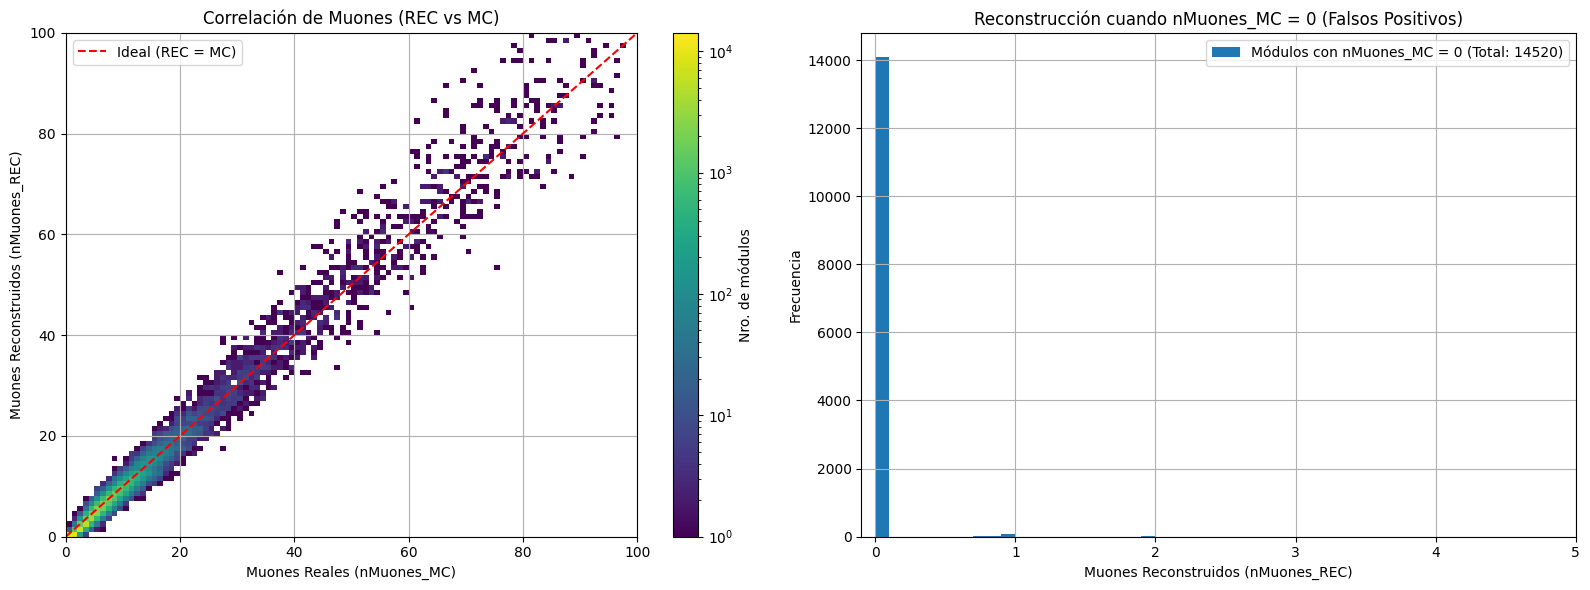

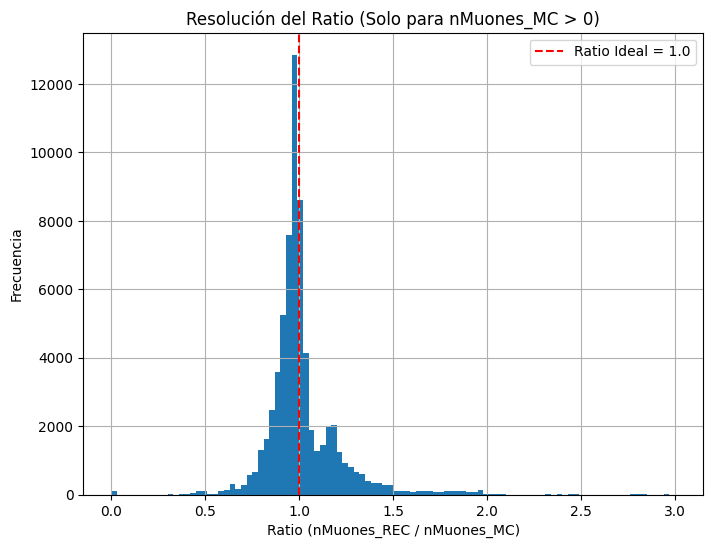


--- Métricas del Ratio (para nMuones_MC > 0) ---
  Promedio (mean): 1.013
  Mediana (median): 0.981
  Resolución (std dev): 0.196


In [14]:
# --- 1. Cargar el DataFrame de prueba (v7) ---
parquet_dir_v7 = "/home/lsilva/Github/Prueba_ADST_Alexey/parquet_v2/" 
all_parquet_files_v7 = glob.glob(os.path.join(parquet_dir_v7, "*.parquet"))

if not all_parquet_files_v7:
    print(f"¡ERROR! No se encontró ningún archivo en {parquet_dir_v7}")
else:
    parquet_path_v7 = all_parquet_files_v7[0]
    print(f"Cargando archivo de prueba: {os.path.basename(parquet_path_v7)}")
    
    df_test = pd.read_parquet(parquet_path_v7)
    print(f"DataFrame 'df_test' cargado con {len(df_test)} filas (módulos).")

    # --- 2. Aplicar solo filtros de CALIDAD ---
    # (Ya no filtramos por nMuones_MC > 0)
    status_buenos = ['candidate', 'rejected', 'saturated']
    df_test_limpio = df_test[
        (df_test['module_status'].isin(status_buenos))
    ].copy()
    
    print(f"Analizando {len(df_test_limpio)} módulos con status 'bueno'.")

    # --- 3. Plot 1: Correlación 2D (Visión General) ---
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    
    # Ploteamos TODOS los puntos (incluyendo los (0, y))
    h = axs[0].hist2d(
        df_test_limpio['nMuones_MC'], 
        df_test_limpio['nMuones_REC'],
        bins=100, 
        norm=LogNorm(), 
        range=[[0, 100], [0, 100]] # Rango
    )
    fig.colorbar(h[3], ax=axs[0], label='Nro. de módulos')
    
    axs[0].plot([0, 100], [0, 100], 'r--', label='Ideal (REC = MC)')
    axs[0].set_xlabel("Muones Reales (nMuones_MC)")
    axs[0].set_ylabel("Muones Reconstruidos (nMuones_REC)")
    axs[0].set_title("Correlación de Muones (REC vs MC)")
    axs[0].legend()
    axs[0].grid(True)

    # --- 4. Plot 2: Tasa de Falsos Positivos (¡TU PREGUNTA!) ---
    
    # Filtramos SÓLO los módulos donde NO hubo muones
    df_mc_zero = df_test_limpio[df_test_limpio['nMuones_MC'] == 0]
    
    print(f"\nEncontrados {len(df_mc_zero)} módulos con nMuones_MC = 0.")
    
    # Hacemos un histograma de lo que RECONSTRUIMOS en esos casos
    axs[1].hist(df_mc_zero['nMuones_REC'], bins=50, range=(0, 5), 
                label=f"Módulos con nMuones_MC = 0 (Total: {len(df_mc_zero)})")
    
    axs[1].set_xlabel("Muones Reconstruidos (nMuones_REC)")
    axs[1].set_ylabel("Frecuencia")
    axs[1].set_title("Reconstrucción cuando nMuones_MC = 0 (Falsos Positivos)")
    axs[1].legend()
    axs[1].grid(True)
    # Hacemos zoom en los valores bajos, que es donde están los falsos positivos
    axs[1].set_xlim(-0.1, 5) 

    plt.tight_layout()
    plt.show()

    # --- 5. Plot 3: Resolución del Ratio (El que teníamos antes) ---
    # (Lo hacemos en una figura separada)
    
    # Ahora sí, filtramos los que tienen señal MC
    df_mc_signal = df_test_limpio[df_test_limpio['nMuones_MC'] > 0].copy()
    df_mc_signal['muon_ratio'] = df_mc_signal['nMuones_REC'] / df_mc_signal['nMuones_MC']

    plt.figure(figsize=(8, 6))
    plt.hist(df_mc_signal['muon_ratio'], bins=100, range=[0, 3])
    plt.xlabel("Ratio (nMuones_REC / nMuones_MC)")
    plt.ylabel("Frecuencia")
    plt.title("Resolución del Ratio (Solo para nMuones_MC > 0)")
    plt.axvline(1.0, color='r', linestyle='--', label='Ratio Ideal = 1.0')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- 6. Métricas de Resumen ---
    print("\n--- Métricas del Ratio (para nMuones_MC > 0) ---")
    print(f"  Promedio (mean): {df_mc_signal['muon_ratio'].mean():.3f}")
    print(f"  Mediana (median): {df_mc_signal['muon_ratio'].median():.3f}")
    print(f"  Resolución (std dev): {df_mc_signal['muon_ratio'].std():.3f}")